# **Retrieve data from the CSV files** 
#### all tables concecated into one dataframe, calculate the mean per month and put it into one csv file called: mean_pm2.5_monthlyvalues.csv
In 1990, pm2.5 and pm10 weren't being tracked yet. So we'll start from 2016 onwards.


In [2]:
import pandas as pd
import numpy as np

urls = [ 
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2016/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2017/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2018/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2019/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2020/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2021/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2022/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2023/',
    'https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/2024/',
]
csv_suffix = '_PM25.csv' 
all_dfs = [] 


for base_url in urls:
    
    year = base_url.split('/')[-2]
    file_name = year + csv_suffix
    full_url = base_url + file_name 
    
   
    temp_df = pd.read_csv(
        full_url, 
        sep=';', 
        skiprows=5 
    )
    
    all_dfs.append(temp_df)
    print(f"loaded: {file_name}")

#Combine data into one df
main_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total instances: {len(main_df)}")


loaded: 2016_PM25.csv
loaded: 2017_PM25.csv
loaded: 2018_PM25.csv
loaded: 2019_PM25.csv
loaded: 2020_PM25.csv
loaded: 2021_PM25.csv
loaded: 2022_PM25.csv
loaded: 2023_PM25.csv
loaded: 2024_PM25.csv
Total instances: 4110905


In [ ]:
import pandas as pd 
for x in main_df.columns:
    num_unique_values = main_df[x].nunique()
    print(f"Column '{x}' has {num_unique_values} unique values.")

#Unique location IDs for province mapping
sorted_unique_values = main_df['meetlocatie_id'].unique()
sorted_unique_values.sort()

print()
print("Sorted Unique meetreeks IDs:")
print(sorted_unique_values)

Column 'meetreeks_id' has 66 unique values.
Column 'meetlocatie_id' has 66 unique values.
Column 'bron_id' has 6 unique values.
Column 'accreditatienummer' has 4 unique values.
Column 'component' has 1 unique values.
Column 'matrix' has 1 unique values.
Column 'meetopstelling_id' has 2 unique values.
Column 'meetduur' has 1 unique values.
Column 'eenheid' has 1 unique values.
Column 'begindatumtijd' has 78912 unique values.
Column 'einddatumtijd' has 78912 unique values.
Column 'waarde' has 33492 unique values.
Column 'opm_code' has 0 unique values.

Sorted Unique meetreeks IDs:
['NL01483' 'NL01485' 'NL01487' 'NL01488' 'NL01489' 'NL01491' 'NL01493'
 'NL01494' 'NL01495' 'NL01496' 'NL01497' 'NL01912' 'NL01913' 'NL10131'
 'NL10136' 'NL10138' 'NL10230' 'NL10240' 'NL10241' 'NL10247' 'NL10248'
 'NL10404' 'NL10418' 'NL10433' 'NL10444' 'NL10448' 'NL10449' 'NL10450'
 'NL10538' 'NL10547' 'NL10636' 'NL10641' 'NL10643' 'NL10644' 'NL10738'
 'NL10741' 'NL10742' 'NL10821' 'NL10934' 'NL10937' 'NL10938

: 

# The nature and structure of the dataset. 
#### source: https://data.rivm.nl/data/luchtmeetnet/readme.pdf

#### Format of the data:
- The data is Time-Series. It consists of sequential measurements of NO₂ concentration taken at specific dates and times across multiple monitoring stations in the Netherlands.

#### Number of instances:
- The exact number will be determined by code output (len(main_df)). Total amount of records in the combined csv dataset (len(df)): 6.666.197. This amount is excluding the headers in the first 5 rows of every dataset


#### Representativity and bias:
- The data is representative of all measuring statements in the netherlands at all times. Different monitoring networks have been used in order to gather the NO2 values.

#### Data structure:
- The data structure is Tabular. It is also relational in that each measurement belongs to a specific date, time, and location.


In [ ]:
import pandas as pd

data_dict = {
    'Variable Name': [
        'meetreeks',              
        'meetlocatie',            
        'bron_id',                
        'accredidatie',           
        'componenten',            
        'matrix',                 
        'meetopstelling_id',      
        'eenheid',                
        'begindatum',             
        'einddatum',              
        'waarde',                 
        'opm_code'                
    ],
    'Description or Meaning': [
        'identifier for the measurement series. ', 
        'identifier for the sampling location.', 
        'identifier for the source (i.e., the monitoring network)', 
        'accreditation number under which the measurements are carried out by a measuring network.', 
        'pollutant shorthand name, also used as an identifier. ', 
        'the environment which contains the pollutant. ', 
        'identifier for the measuring setup (i.e., the used measurement equipment)', 
        'the measurement duration of the measurements. ', 
        'start date time of the measurement.', 
        'end date time of the measurement.', 
        'measurement value', 
        'identifier for remarks.'
    ],
    'Data Type': [
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'string', 
        'Float64', 
        'string'
    ],
    'Units or Scale': [
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'YYYY-MM-DD HH:MM:SS', 
        'YYYY-MM-DD HH:MM:SS', 
        'micrograms per cubic meter', 
        'N/A'
    ],
    'Encoding': [
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'N/A', 
        'Int', 
        'N/A'
    ]
}

data_dictionary_df = pd.DataFrame(data_dict)
data_dictionary_df = data_dictionary_df.set_index('Variable Name')

data_dictionary_df

## potential data quality problems


In [ ]:
import pandas as pd

# Stel Pandas display-opties in om alle kolommen en rijen in de output te zien
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


# no scientific notation
pd.set_option('display.float_format', '{:.0f}'.format)

print(main_df.describe(include='all'))
print(main_df[['waarde']].describe())

nan_count = main_df.isnull().sum()
total_rows = len(main_df)
missing_data = nan_count[nan_count > 0]
missing_data = missing_data.sort_values(ascending=False)

if 'waarde' in missing_data.index:
    waarde_missing_info = missing_data.loc[['waarde']]
    print(waarde_missing_info)
else:
    print("There are no NAN values in the 'waarde' column.")

In [ ]:
main_df.info()

#description of df
print(main_df[['waarde']].describe())



# Analyse the distribution for all variables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
ax= main_df.plot(
    kind='hist', 
    bins=100, 
    title='Distribution of PM25 values'
)
plt.xlim(-20, 100)
plt.ylabel("Frequency") 
plt.xlabel("NO2 value in micograms per cubic meter")

plt.show()

In [5]:
import pandas as pd
from scipy.stats import skew 


waarde_data = main_df['waarde']

skew_value = waarde_data.skew()


print(skew_value)

8.937464256758211


## Duplicate instances 

In [ ]:
import pandas as pd
duplicate_count = main_df.duplicated().sum()

if duplicate_count > 0:
    print(f"Found {duplicate_count} instances")
else:
    print("No duplicate instances found.")

## Outliers

In [ ]:
import pandas as pd

pd.set_option('display.float_format', '{:.4f}'.format)
print(main_df[['waarde']].describe())


In [ ]:
import pandas as pd
import numpy as np

#minimum value
min_waarde = main_df['waarde'].min()
min_waarde_frequentie = (main_df['waarde'] == min_waarde).sum()

#maximum value
max_waarde = main_df['waarde'].max()
max_waarde_frequentie = (main_df['waarde'] == max_waarde).sum()

#values less than or equal to 0
# are necessary 
# because they ensure the Boolean operation is completed before the attempts to count the results. 
nonpositive_values = (main_df['waarde'] <= 0).sum()


#minimum and frequencency
print(f"Minimum value in dataset: {min_waarde:.0f}")
print(f"Frequency minimum value: {min_waarde_frequentie}")

#maximum and frequencency
print(f"Maximum value in dataset: {max_waarde:.0f}")
print(f"Frequency of maximum value: {max_waarde_frequentie}")

#non_positive values
print(f"Frequency of No2 values below  or equal to 0: {nonpositive_values}")

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(9, 6))
plt.boxplot(
    main_df['waarde'], 
    vert=True, 
    patch_artist=True
)
#limit set at 50 eventhough max is 1558, for better vissualization
plt.ylim(-20, 50)


plt.title("Box Plot: Distribution NO2 value")
plt.ylabel("NO2 value")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

sns.violinplot(
    y=main_df['waarde'],
    inner='quartile', 
    color='lightcoral',
    linewidth=1.5
)

plt.ylim(-20, 100) 

plt.title("Violin Plot: NO2 distribution (density)")
plt.ylabel("NO2 value")
plt.grid(True, axis='y', alpha=0.5)
plt.show()

## Seaborn visualizations

In [ ]:
!pip install seaborn


In [ ]:
import scipy.stats as stats
import seaborn as sns 
plt.figure(figsize=(10, 6))
sns.histplot(
    main_df['waarde'], 
    bins=100, 
    kde=True
)
plt.figure(figsize=(6, 6))
stats.probplot(
    main_df['waarde'], 
    dist="norm", 
    plot=plt
)
plt.title("QQ Plot: Controle on normality (NO2 Waarde)")
plt.show()

In [27]:
print(main_df['waarde'].skew())


9.229200132881157


## Distribution of the 0 and negative values according to meetset_id

In [2]:
import pandas as pd

non_positive_df = main_df[main_df['waarde'] <= 0]

if non_positive_df.empty:
    print("No values found that are 0 or less.")
else:
    # returns a series
    error_counts = non_positive_df['meetreeks_id'].value_counts()
    
    # convert series to dataFrame
    error_table_df = error_counts.reset_index()
    
    print(error_table_df)

           meetreeks_id  count
0   NL10644_PM2.5_lucht   6395
1   NL10821_PM2.5_lucht   6216
2   NL10404_PM2.5_lucht   5909
3   NL10138_PM2.5_lucht   5377
4   NL10938_PM2.5_lucht   5359
..                  ...    ...
60  NL01485_PM2.5_lucht     29
61  NL49680_PM2.5_lucht     20
62  NL01912_PM2.5_lucht     18
63  NL01913_PM2.5_lucht     17
64  NL01493_PM2.5_lucht      3

[65 rows x 2 columns]


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
if 'begindatumtijd' in main_df.columns:
    main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])
    
non_positive_df = main_df[main_df['waarde'] <= 0]

if non_positive_df.empty:
    print("No non-positive values")
else:
    nonpositive_years = non_positive_df['begindatumtijd'].dt.year

    #errors per year
    fouten_per_jaar = nonpositive_years.value_counts()
    
    #df for seaborn
    plot_df = fouten_per_jaar.reset_index(name='non positive values')
    plot_df.columns = ['year', 'non positive values']
    
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='year', 
        y='non positive values', 
        data=plot_df
    )
    plt.title('Count of Non-Positive NO2 Values per source file', fontsize=16)
    plt.xlabel('sourcefile', fontsize=14)
    plt.ylabel('Amount of non positive values', fontsize=14)
    plt.show()

# Cleaning Requirement: All values ≤0 must be imputed to positive values using fillna.
We used the fillna method to fill in the NAN values. This method locates every NAN value in the dataset and fills this instance with the previous instance from the same meetreeks_id. We used this method because the number of instances with NO2 values below or equal to 0 were a small amount in comparison to the total instances. The reason for this method is due to the fact that this datasource is a timeseries.

The result is that there are 2 NaN values left in the dataset. The reason for this is due to the fact that these are the first two measuring points of their respective meetreeks_id. 

These 2 NaN values will be deleted/ignored for the rest of the transformation and training of the model, because the percentage of NaN values is approximately 0,000005 percent



In [ ]:
import numpy as np 
import pandas as pd 

count_non_positive = (main_df['waarde'] <= 0).sum()
print(f"Count of non positive values: {count_non_positive}")

if count_non_positive > 0: 
    #Assign NaN to non positive values
    initial_total_nans = main_df['waarde'].isnull().sum()
    main_df.loc[main_df['waarde'] <= 0, 'waarde'] = np.nan 

    #impute the NAN values with positive values from the previous record with the same meetreeks_id
    main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')
    
print(f"Final NaN values in 'waarde': {main_df['waarde'].isnull().sum()}") 
nan_rows = main_df.loc[main_df['waarde'].isnull()]

print("Rijen met Overgebleven NaN Waarden in 'waarde")
print(nan_rows)

nan_rows = main_df[main_df['waarde'].isnull()]

print(f"Rijen met NaN's worden verwijderd: {len(nan_rows)}")

# De .drop() methode deletes the rows on basis of index
main_df.drop(nan_rows.index, inplace=True)

# Verification
print(f"Control: Nan is now: {main_df['waarde'].isnull().sum()}")

Count of non positive values: 130410


C:\Users\enock\AppData\Local\Temp\ipykernel_36620\4229731047.py:13: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')
C:\Users\enock\AppData\Local\Temp\ipykernel_36620\4229731047.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df['waarde'] = main_df.groupby('meetreeks_id')['waarde'].fillna(method='ffill')


Final NaN values in 'waarde': 2
Rijen met Overgebleven NaN Waarden in 'waarde
                meetreeks_id meetlocatie_id bron_id accreditatienummer  \
1494859  NL10449_PM2.5_lucht        NL10449     LML               L224   
1494860  NL10449_PM2.5_lucht        NL10449     LML               L224   

        component matrix        meetopstelling_id meetduur eenheid  \
1494859     PM2.5  lucht  Bstralingsverzw_BAM1020      uur   µg/m³   
1494860     PM2.5  lucht  Bstralingsverzw_BAM1020      uur   µg/m³   

                    begindatumtijd              einddatumtijd  waarde  \
1494859  2019-03-27T11:00:00+01:00  2019-03-27T12:00:00+01:00     NaN   
1494860  2019-03-27T12:00:00+01:00  2019-03-27T13:00:00+01:00     NaN   

         opm_code  
1494859       NaN  
1494860       NaN  
Rijen met NaN's worden verwijderd: 2
Control: Nan is now: 0


## Data transformation

add province

In [4]:
PM25_pvencoding = meetlocatie_provincie = {
    'NL01483': 'Zuid-Holland',
    'NL01485': 'Zuid-Holland',
    'NL01487': 'Zuid-Holland',
    'NL01488': 'Zuid-Holland',
    'NL01489': 'Zuid-Holland',
    'NL01491': 'Zuid-Holland',
    'NL01493': 'Zuid-Holland',
    'NL01494': 'Zuid-Holland',
    'NL01495': 'Zuid-Holland',
    'NL01496': 'Zuid-Holland',
    'NL01497': 'Zuid-Holland',
    'NL01912': 'Zuid-Holland',
    'NL01913': 'Zuid-Holland',
    'NL10131': 'Limburg',
    'NL10136': 'Limburg',
    'NL10138': 'Limburg',
    'NL10230': 'Noord-Brabant',
    'NL10240': 'Noord-Brabant',
    'NL10241': 'Noord-Brabant',
    'NL10247': 'Noord-Brabant',
    'NL10248': 'Noord-Brabant',
    'NL10404': 'Zuid-Holland',
    'NL10418': 'Zuid-Holland',
    'NL10433': 'Zuid-Holland',
    'NL10444': 'Zuid-Holland',
    'NL10449': 'Zuid-Holland',
    'NL10450': 'Zuid-Holland',
    'NL10448': 'Zuid-Holland',
    'NL10538': 'Noord-Holland',
    'NL10547': 'Noord-Holland',
    'NL10636': 'Utrecht',
    'NL10641': 'Utrecht',
    'NL10643': 'Utrecht',
    'NL10644': 'Utrecht',
    'NL10738': 'Gelderland',
    'NL10741': 'Gelderland',
    'NL10742': 'Gelderland',
    'NL10821': 'Overijssel',
    'NL10934': 'Friesland',
    'NL10937': 'Groningen',
    'NL10938': 'Groningen',
    'NL49007': 'Noord-Holland',
    'NL49012': 'Noord-Holland',
    'NL49014': 'Noord-Holland',
    'NL49016': 'Noord-Holland', 
    'NL49017': 'Noord-Holland',
    'NL49551': 'Noord-Holland',
    'NL49553': 'Noord-Holland',
    'NL49556': 'Noord-Holland',
    'NL49557': 'Noord-Holland',
    'NL49561': 'Noord-Holland', 
    'NL49570': 'Noord-Holland', 
    'NL49572': 'Noord-Holland',
    'NL49573': 'Noord-Holland',
    'NL49680': 'Flevoland',
    'NL49701': 'Noord-Holland',
    'NL49703': 'Noord-Holland',
    'NL49704': 'Noord-Holland',
    'NL50003': 'Limburg',
    'NL50004': 'Limburg',
    'NL50006': 'Limburg',
    'NL50007': 'Limburg',
    'NL50009': 'Limburg',
    'NL50010': 'Limburg',
    'NL53001': 'Noord-Brabant',
    'NL53004': 'Noord-Brabant'
}

# match province to meetlocatie_id
main_df['province'] = main_df['meetlocatie_id'].map(PM25_pvencoding)

# Select columns of df
dfpm25 = main_df[['province', 'waarde', 'meetlocatie_id']]
print(dfpm25.head(10))


       province  waarde meetlocatie_id
0  Zuid-Holland    41.4        NL01483
1  Zuid-Holland    24.0        NL01483
2  Zuid-Holland    27.4        NL01483
3  Zuid-Holland    20.1        NL01483
4  Zuid-Holland    12.6        NL01483
5  Zuid-Holland    12.5        NL01483
6  Zuid-Holland    10.6        NL01483
7  Zuid-Holland     9.0        NL01483
8  Zuid-Holland    10.3        NL01483
9  Zuid-Holland     9.1        NL01483


make a df with monthly average values, province and year_month

In [5]:
# Convert date columns to datetime format
#main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])

# Add a new column for year and month 
#main_df['Jaar_Maand'] = main_df['begindatumtijd'].dt.to_period('M')

# Group by the new column and calculate the mean of 'waarde'
#dfno2 = main_df.groupby(['Jaar_Maand','province'])['waarde'].mean().reset_index()

# Rename columns 
#dfno2.columns = ['Year_Month', 'province', 'Average NO2 Value']

# Format the columns
#dfno2['Year_Month'] = dfno2['Year_Month'].astype(str)
#print(dfno2.columns)
#Convert date column to datetime
main_df['begindatumtijd'] = pd.to_datetime(main_df['begindatumtijd'])

#Extract the year from the datetime column
main_df['Jaar'] = main_df['begindatumtijd'].dt.year

#Group by year and province, then calculate the mean NO₂ value
dfpm25 = (
    main_df.groupby(['Jaar', 'province'])['waarde']
    .mean()
    .reset_index()
)

#Rename columns
dfpm25.columns = ['Year', 'province', 'Average PM2.5 Value']

#Correct data type for 'Year' column
dfpm25['Year'] = dfpm25['Year'].astype(int)

#Display the first few rows
print(dfpm25.head())


   Year       province  Average PM2.5 Value
0  2016      Friesland             9.021771
1  2016     Gelderland            10.469228
2  2016      Groningen            10.715954
3  2016        Limburg            11.057369
4  2016  Noord-Brabant            12.416639


**Log transformation**

In [9]:
a = dfpm25['Average PM2.5 Value']
c = abs(a.min())

In [10]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt



shift = a + c + 0.001
log_x = np.log(shift)  
print(log_x)

0     2.721670
1     2.812599
2     2.827306
3     2.847307
4     2.923192
        ...   
77    2.766444
78    2.709144
79    2.556291
80    2.754850
81    2.693561
Name: Average PM2.5 Value, Length: 82, dtype: float64


In [11]:
log_x.skew()


np.float64(-0.31348908100801687)

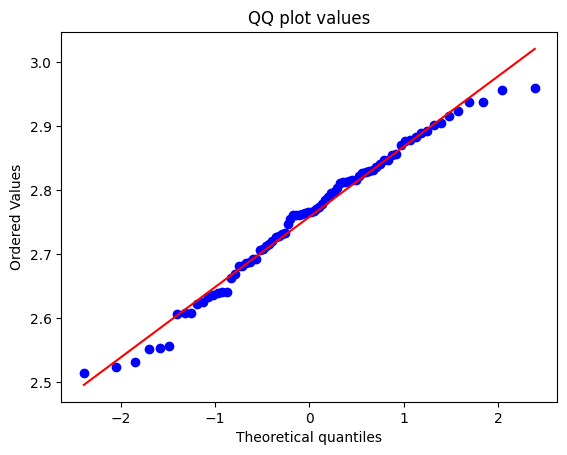

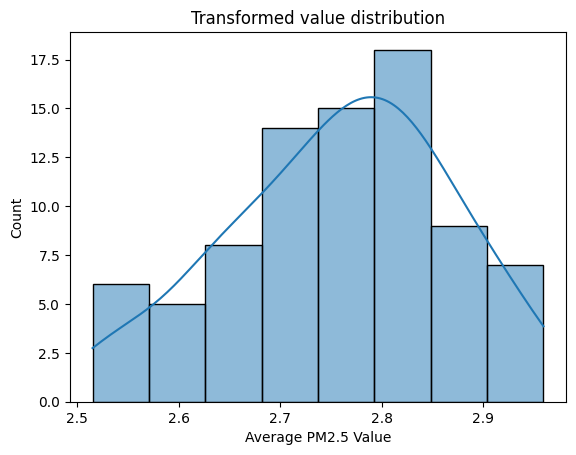

In [12]:
import seaborn as sns 

stats.probplot(log_x, dist="norm", plot=plt)
plt.title("QQ plot values")
plt.show()

sns.histplot(log_x,kde=True)
plt.title("Transformed value distribution")
plt.show()

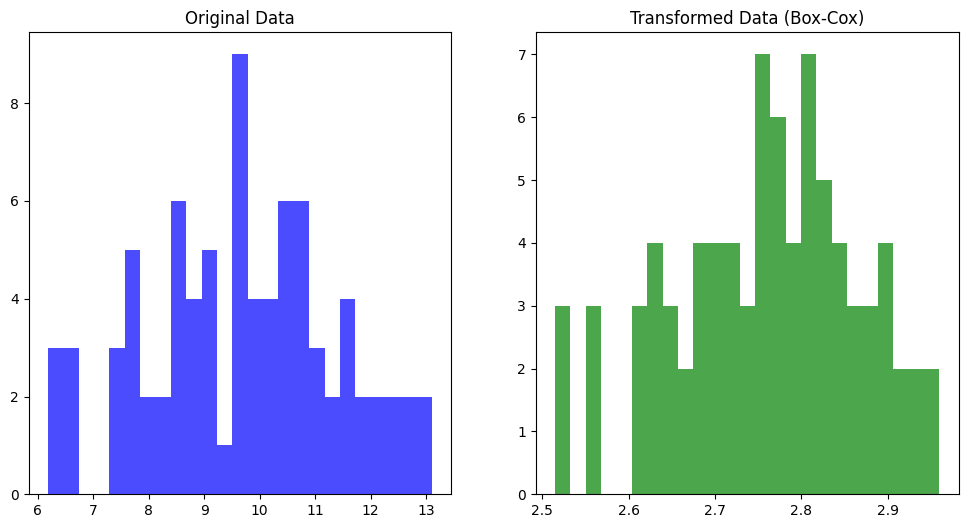

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(a, bins=25, color='blue', alpha=0.7)
plt.title('Original Data')

plt.subplot(1, 2, 2)
plt.hist(log_x, bins=25, color='green', alpha=0.7)
plt.title('Transformed Data (Box-Cox)')

plt.show()

In [14]:
%pip install scikit-learn
from sklearn.preprocessing import StandardScaler

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\enock\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#### Since the log_x values are stored as series instead of dataframe, we need to reshape the data. Since we mainly want to use numerical data for the prediction part we scale them so that they will have the same impact on the clustering algorithms (which are sensitive to different data scales). Moreover, it is less sensitive to outliers (compared to minmax() scaling), helping us reduce the impact of these outliers. 
- https://stackoverflow.com/questions/35723472/how-to-use-sklearn-fit-transform-with-pandas-and-return-dataframe-instead-of-num

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize the log-transformed NO₂ values
standardizePM25 = StandardScaler().fit_transform(log_x.values.reshape(-1, 1))

# Build a  DataFrame instead of a Series
dfstandardizationPM25 = pd.DataFrame({
    'Year': dfpm25['Year'].values,
    'province': dfpm25['province'].values,
    'Standardized_PM25': standardizePM25.flatten()
})

# result
print(dfstandardizationPM25.head())
print(f"Skewness of standardized PM25:", dfstandardizationPM25['Standardized_PM25'].skew())


   Year       province  Standardized_PM25
0  2016      Friesland          -0.341097
1  2016     Gelderland           0.500776
2  2016      Groningen           0.636940
3  2016        Limburg           0.822119
4  2016  Noord-Brabant           1.524698
Skewness of standardized PM25: -0.31348908100801454


## Linear regression 

As you can see there is no clear trend with this dataset. There is no clear linear negative correlation between the pollutant and the years, so 

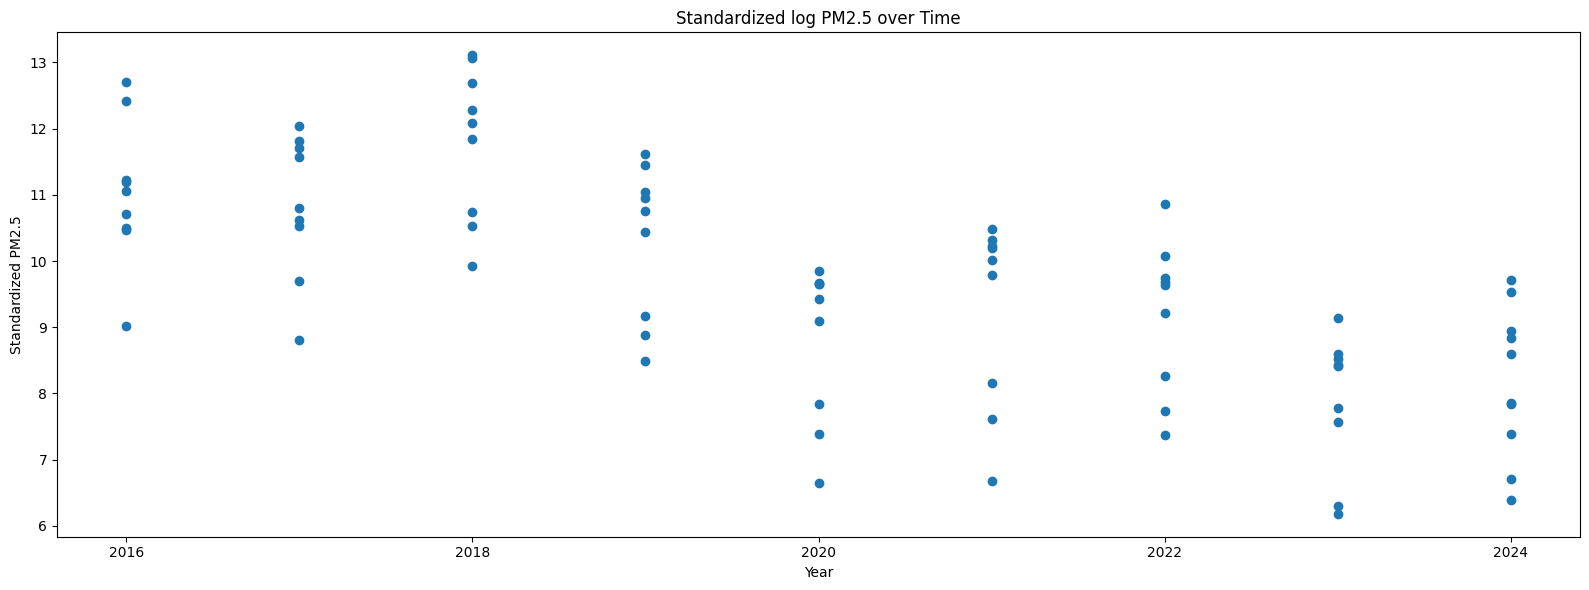

In [ ]:
import matplotlib.pyplot as plt

# make sure it's numeric
dfpm25['Year'] = dfpm25['Year'].astype(int)

plt.figure(figsize=(16, 6))
plt.scatter(
    dfpm25['Year'],
    dfpm25['Average PM2.5 Value']
)

plt.title("Standardized log PM2.5 over Time")
plt.xlabel("Year")
plt.ylabel("Standardized PM2.5")

years = sorted(dfpm25['Year'].unique())

plt.tight_layout()
plt.show()


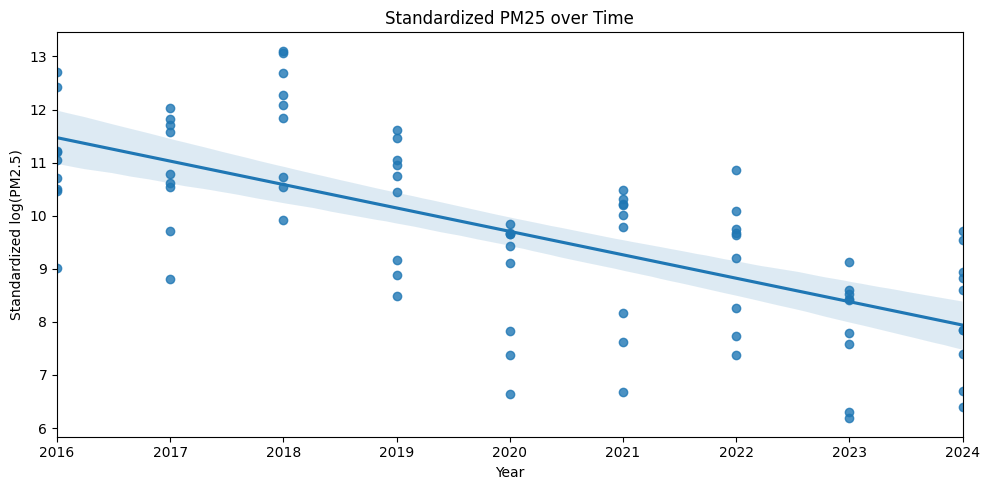

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(10, 5))
ax = plt.gca()

sns.regplot(
    x='Year',
    y='Average PM2.5 Value',
    data=dfpm25
)

# Labels and formatting
ax.set_title("Standardized PM25 over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Standardized log(PM2.5)")

years = sorted(dfpm25['Year'].unique())

# limits
ax.set_xlim(dfpm25['Year'].min(), dfpm25['Year'].max())

plt.tight_layout()
plt.show()


### This block of code is to train the model
https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_yearly = (
    dfpm25
    .groupby(['Year', 'province'], as_index=False)  ['Average PM2.5 Value']
    .mean()
    .dropna()
)

# features and target
X = df_yearly[['Year', 'province']]
y = df_yearly['Average PM2.5 Value']  #raw value target 

# necessary when “province” is included as a predictor in model. Because scikit can't handle string data
# flevoland didn't appear in the earlier testdata so if the model doesn't see a province with certain values, it  fills it with dummy data
preprocessor = ColumnTransformer(
    transformers=[
        ('province',
         OneHotEncoder(drop='first', handle_unknown='ignore'), 
         ['province'])
    ],
    remainder='passthrough' #keeps year column
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

### This block of code is to predict and save the values into a csv file

In [16]:
import pandas as pd

# Load the monthly predictions
monthly = pd.read_csv('predicted_PM25values_mean_monthly_2025_2031.csv')

# Extract the year from Year_Month
monthly['Year'] = monthly['Year_Month'].str[:4].astype(int)

# Group by year and province, then take the mean
yearly = (
    monthly.groupby(['Year', 'province'], as_index=False)['Average_predicted_PM25']
    .mean()
)

# Round the predicted values to integers
yearly['Average_predicted_PM25'] = yearly['Average_predicted_PM25'].round(0).astype('Int64')

# Save the result
yearly.to_csv('predicted_PM25values_yearly_2025_2031.csv', index=False)

print("Saved: predicted_PM25values_yearly_2025_2031.csv")
print(yearly.head(12))

Saved: predicted_PM25values_yearly_2025_2031.csv
    Year       province  Average_predicted_PM25
0   2025      Flevoland                       7
1   2025      Friesland                       5
2   2025     Gelderland                       8
3   2025      Groningen                       6
4   2025        Limburg                       8
5   2025  Noord-Brabant                       9
6   2025  Noord-Holland                       8
7   2025     Overijssel                       6
8   2025        Utrecht                       8
9   2025   Zuid-Holland                       8
10  2026      Flevoland                       7
11  2026      Friesland                       5


#### Validation of the regression model with Time series validation
https://www.w3schools.com/python/python_ml_cross_validation.asp

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=10)
scores_yearly = cross_val_score(model, X, y, cv=tscv, scoring='r2')

# Results
print("Yearly R² per fold:", scores_yearly)
print("Mean Yearly R²:", scores_yearly.mean())
print("Number of folds used:", len(scores_yearly))


Yearly R² per fold: [ 0.25745495 -0.01366897 -0.13648997 -0.18209024 -0.11217283  0.7632004
  0.73575488  0.7593856  -0.43044518  0.51068225]
Mean Yearly R²: 0.2151610900333955
Number of folds used: 10


C:\Users\enock\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
model.fit(X, y)             

y_pred = model.predict(X)


# Fit  model 
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate MSE
MSE = np.square(y - y_pred).mean()

# Calculate Root Mean Squared Error 
RMSE = np.sqrt(MSE)

print(f"Mean Squared Error: {MSE}")
print(f"Root Mean Squared Error: {RMSE}")


Mean Squared Error: 0.4888
Root Mean Squared Error: 0.6992


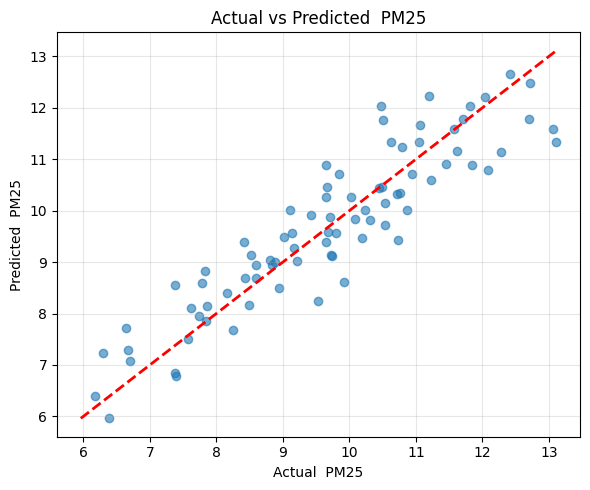

In [ ]:
import matplotlib.pyplot as plt

# Fit  model and get predictions
model.fit(X, y)
y_pred = model.predict(X)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

# Plot Actual vs Predicted  PM2.5
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel("Actual  PM25")
plt.ylabel("Predicted  PM25")
plt.title("Actual vs Predicted  PM25")
plt.show()